# In-Class Activity (July 7, 2026)

In [1]:
library(tidyverse)
library(moderndive)

── Attaching core tidyverse packages ─────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.1     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.3     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.2     
── Conflicts ───────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


In [2]:
wage_data <- read.table("data/wage.txt", header=TRUE)
head(wage_data)

,education,south,sex,experience,union,wage,age,race,occupation,sector,marr
,<int>,<int>,<int>,<int>,<int>,<dbl>,<int>,<int>,<int>,<int>,<int>
1,8,0,1,21,0,5.10,35,2,6,1,1
2,9,0,1,42,0,4.95,57,3,6,1,1
3,12,0,0,1,0,6.67,19,3,6,1,0
4,12,0,0,4,0,4.00,22,3,6,0,0
5,12,0,0,17,0,7.50,35,3,6,0,1
6,13,0,0,9,1,13.07,28,3,6,0,0


### (Part A): Plot WAGE versus EDUCATION. Is there a linear relationship between them?

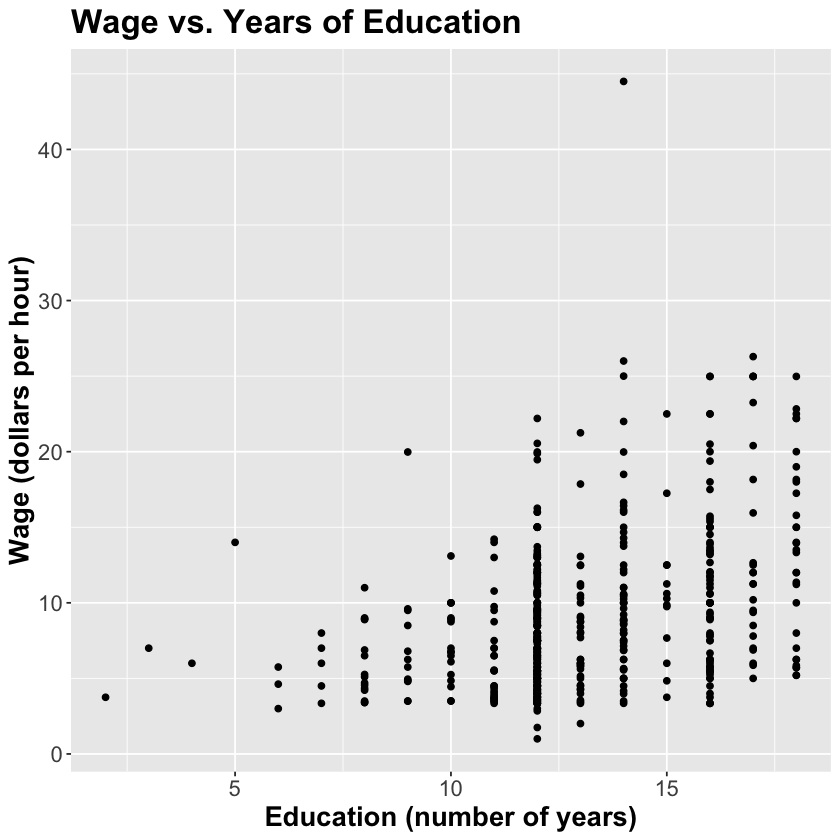

In [3]:
wage_scatterplot <- ggplot(wage_data, aes(education, wage)) +
  geom_point() +
  xlab("Education (number of years)") +
  ylab("Wage (dollars per hour)") +
  ggtitle("Wage vs. Years of Education") +
  theme(
    text = element_text(size = 16.5),
    plot.title = element_text(face = "bold"),
    axis.title = element_text(face = "bold")
  )
wage_scatterplot

Yes, there is a linear relationship between education and wage, however this linear relationship is weak. We can observe that as the eduction increases, the wage increases, however we can visually see that the correlation between these two variables is not very strong.

### (Part B): Find the correlation coefficient of the two variables. Is it consistent with what you observe in (A)?

In [4]:
wage_data %>% 
  get_correlation(formula = wage ~ education)

cor
<dbl>
0.3819221


In [5]:
cor(wage_data$wage, wage_data$education)

[1] 0.3819221

This value is consistent with what I observed in Part A since I claimed there was a "weak" linear relationship between the two variables. The correlation coefficient `0.3819221` indicates that these two variables are weakly correlated. It also indicates that there is a positive correlation between them, meaning that as the number of years of education increases, the the wage also increases. Note that this value simply indicates the correlation between these two variables and does not indicate causation.

Note, I found the correlation using both get_correlation() and cor() which both produced the same value: `0.3819221...`

### (Part C) Fit a simple linear regression model, with WAGE as response and EDUCATION as a predictor. Is the result consistent with (A) and (B)?

In [6]:
wage_model <- lm(wage ~ education, data = wage_data)
get_regression_table(wage_model)

term,estimate,std_error,statistic,p_value,lower_ci,upper_ci
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
intercept,-0.746,1.045,-0.714,0.476,-2.800,1.308
education,0.750,0.079,9.532,0.000,0.596,0.905


The result from fitting the simple linear regression model is consistent with Parts A and B since the fitted model exhibits a positive slope of `0.750` (i.e. a positive value for the `estimate` for education). This positive slope is consistent with the positive correlation that I identified both visually in part A, and programmatically in part B.

Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”
`geom_smooth()` using formula = 'y ~ x'


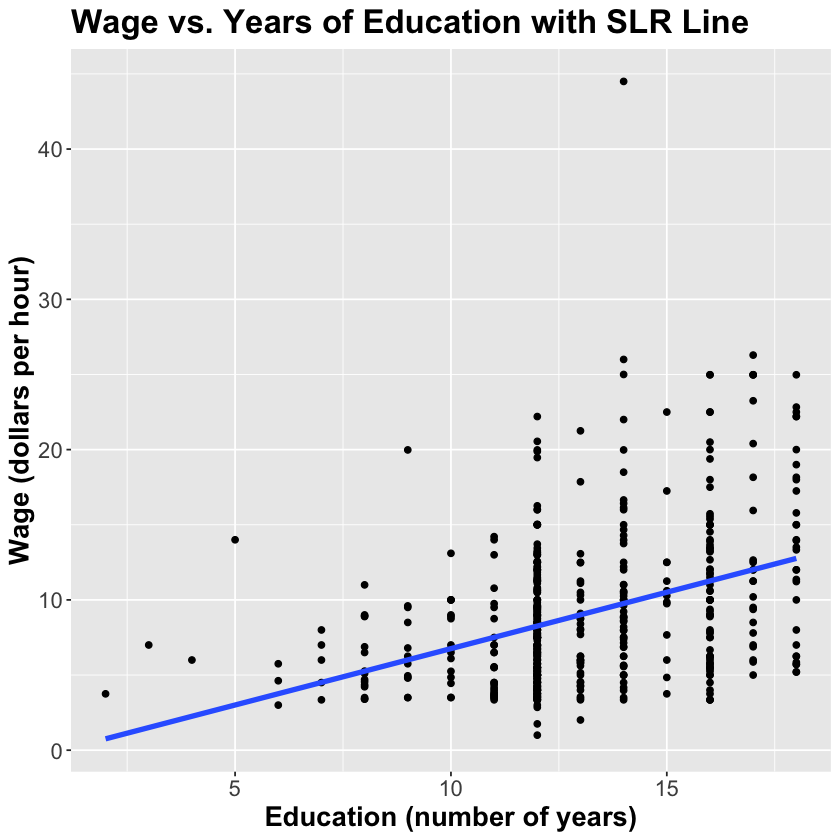

In [7]:
wage_scatterplot <- ggplot(wage_data, aes(education, wage)) +
  geom_point() +
  geom_smooth(method = "lm", se = FALSE, size = 1.5) +
  xlab("Education (number of years)") +
  ylab("Wage (dollars per hour)") +
  ggtitle("Wage vs. Years of Education with SLR Line") +
  theme(
    text = element_text(size = 16.5),
    plot.title = element_text(face = "bold"),
    axis.title = element_text(face = "bold")
  )

wage_scatterplot

In addition to fitting the model and displaying the numerical details of the fitted model, I also plotted the resulting graph which visually shows the linear line going through the points in the upwards direction which further corroborates the conclusions I've made in previous parts regarding the linear pattern of the data.